In [69]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [70]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
Tesla T4


## getting dataset

In [71]:
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = transforms.ToTensor(),
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = transforms.ToTensor(),
    target_transform = None
)

In [72]:
img,label = train_data[0]
print(img.shape)
print(label)

torch.Size([1, 28, 28])
9


In [73]:
class_name = train_data.classes
cls_ind = train_data.class_to_idx
print(class_name)
print(cls_ind)
print(train_data.targets)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
tensor([9, 0, 0,  ..., 3, 0, 5])


## visualize the sample data

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

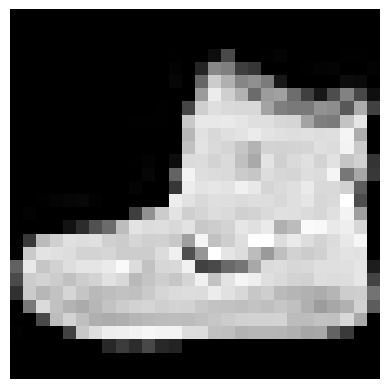

In [74]:
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(),cmap="gray")
plt.axis(False)

37542
46067
46876
46414
10026
27335
38620
11924
14950
57113
31378
29014
47210
18954
18231
47572


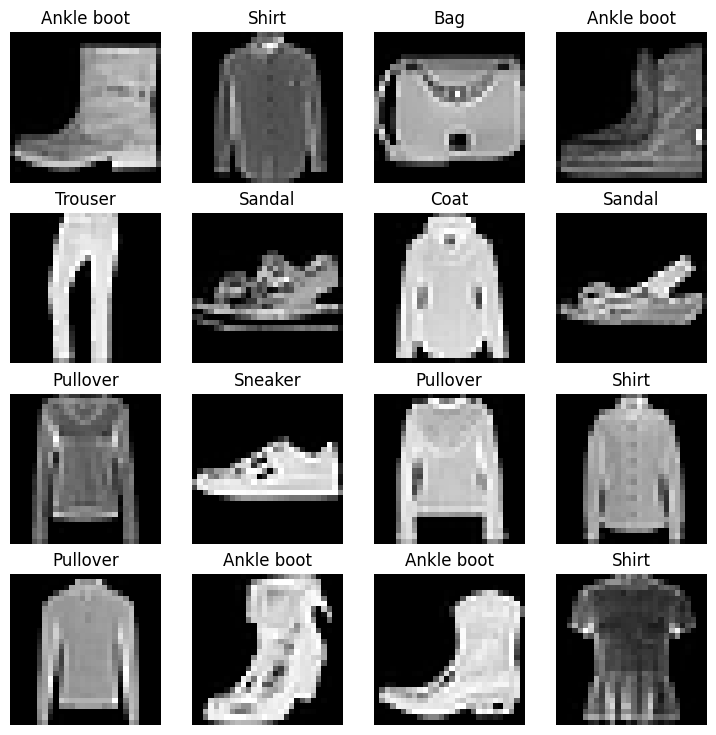

In [75]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
    rand_ind = torch.randint(0,len(train_data),size=[1]).item()
    print(rand_ind)
    image,labels = train_data[rand_ind]
    fig.add_subplot(rows,cols,i)
    plt.imshow(image.squeeze(),cmap="gray")
    plt.title(class_name[labels])
    plt.axis(False)


## dataloader and minibatches

torch.Size([1, 28, 28])


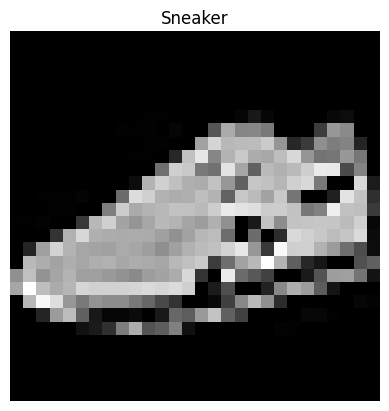

In [84]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_data_loader = DataLoader(dataset = train_data,
                               batch_size = BATCH_SIZE,
                               shuffle = True)

test_data_loader = DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              shuffle =False)

print(train_data_loader)
print(test_data_loader)
train_feat,train_label = next(iter(train_data_loader))
torch.manual_seed(42)
ran_ind = torch.randint(0,len(train_feat),size=[1]).item()
image1,label1 =  train_feat[ran_ind],train_label[ran_ind]
plt.imshow(image1.squeeze(),cmap="gray")
plt.title(class_name[label1])
plt.axis(False)
print(image1.shape)